# ModelOps: own, approve, roll back and retire a model

Runnable locally on CPU or on a Cloud TPU VM.

- Inventory the complete release
- Bind review to immutable evidence
- Make failed transitions leave no side effects
- Separate selection, rollout and monitoring

A model passed evaluation last week. Someone changed its preprocessing or image today and reused the old approval. Let’s bind a review to the exact release bundle, reject stale decisions and preserve the current version when a gate fails.

## The idea

Model governance connects ownership, evaluation, approval and lifecycle transitions. An approval should identify exactly what was reviewed, where it may be used and when it remains valid. A label saying approved is not enough.

## Approval applies to a specific release

Suppose a model passes review, then its tokenizer or weights change. Reusing the old approval would apply a decision to an object that was never evaluated under that identity. Bind approvals to the relevant model, processor, configuration and evaluation records.

Specify transitions for activation, expiration, rejection and retirement. Invalid transitions should leave the active state unchanged rather than partially applying a release. A retired artifact may remain archived for reproducibility while no longer being eligible for new use.

The acceptance bars are summaries of discrete policy decisions. Read the underlying state and reason for each result. The fixture demonstrates decision logic, not completion of an organization's actual review process.

$$
S_{\text{cos}}(q, d_i) = \frac{\langle E(q), E(d_i) \rangle}{\|E(q)\|_2 \, \|E(d_i)\|_2}
$$

### Pause and reason

Does changing a display name require the same response as changing weights?

<details><summary>Compare your reasoning</summary>

Not necessarily. Define which identities and semantics the policy binds. A cosmetic label and a changed numerical artifact are different events, and the policy should distinguish them explicitly.

</details>

## Inventory the complete release

Record the model artifact, data/evaluation identity, image digest, preprocessing/signature, precision, intended target and responsible owner. The fixture compresses that into a small bundle with model, data and evaluation hashes, image digest, owner, target and passing result. Real release records should also identify training/code versions, documented limitations, dependency/license obligations where applicable, and how to reach the owner. Registry tags help discovery but are not access control.

## Bind review to immutable evidence

Hash the whole release bundle, then record who reviewed that hash and when the approval expires. If the model, evaluation, image, target or owner changes, the hash changes and the old approval must not authorize the new bundle. The local function receives a reviewer string as a fixture: it does not authenticate that person. A production workflow needs trusted identity, authorization, protected evidence and an audit log. A checksum proves equality of bytes, not authority or model quality.

## Make failed transitions leave no side effects

The example validates the bundle and approval before writing the active pointer. It uses an atomic rename for a single local writer. A failed validation must leave the previous selection byte-for-byte unchanged. With multiple deployment controllers, use a transactional compare-and-swap or a deployment system with concurrency control; atomic file replacement alone does not prevent competing writers from losing updates.

## Separate selection, rollout and monitoring

A registry alias chooses a version. A rollout changes serving processes and traffic. Monitor the loaded model/image identity as well as quality and service signals to detect disagreement. Canary and shadow releases answer different questions: a canary serves a limited live population, while shadow traffic runs a candidate without using its answer. Define stop conditions, traffic assignment and comparable metrics before observing a favorable curve.

## Rollback needs its own valid target

Keeping a previous pointer is useful but does not guarantee the old artifact still loads, remains approved or matches the current input contract. Revalidate compatibility, artifact availability and approval before rolling back. Practice a rejected rollout and a successful rollback using a known previous bundle. Retire a model by stopping new traffic, removing inappropriate aliases/access and applying the organization’s retention rules to evidence; do not silently delete the only audit trail.

## Work through the four decisions

The fixture accepts the original bundle at time $150$, then rejects changed model bytes, an approval expiring at $200$, and a different target. The valid interval is $[100,200)$: expiration is exclusive. The image digest in this companion is explicitly a format-valid test value. Replace it with the observed container image identity in the connected project before treating the record as deployment evidence.

**Run changed-bundle and expiry checks**

```bash
# Run run changed-bundle and expiry checks using the course Python environment
python projects/engineering-release/tests/check.py --implementation solution --stage 3
```

**Expected:** The gate accepts only the matching, current bundle and every failure preserves the active pointer.

## Prepare the explicit contract

Create main.py and add this setup block. Continue with the next block in the same file.

In [1]:
# Step 1 — Prepare the explicit contract: Record the model artifact, data/evaluation identity, image digest,...
# Import hashlib, json, math, tempfile for this computation.
import hashlib, json, math, tempfile
from pathlib import Path

Record the model artifact, data/evaluation identity, image digest, preprocessing/signature, precision, intended target and responsible owner. The fixture compresses that into a small bundle with model, data and evaluation hashes, image digest, owner, target and passing result. Real release records should also identify training/code versions, documented limitations, dependency/license obligations where applicable, and how to reach the owner. Registry tags help discovery but are not access control.

## Run and inspect the controlled experiment

Append this block, run main.py in the course environment, and retain the actual output.

In [2]:
# Step 2 — Run and inspect the controlled experiment: A registry alias chooses a version.
def digest(value):
    # Return `hashlib.sha256(json.dumps(value, sort_keys=True, separators=(',', ':'), allow_nan=False).encode()).hexdigest()` to the caller.
    return hashlib.sha256(json.dumps(value, sort_keys=True, separators=(',', ':'), allow_nan=False).encode()).hexdigest()

# Function `approval_for(bundle, actor, now, expires)` implementing this stage's computation:
def approval_for(bundle, actor, now, expires):
    # Guard input contract (`not actor or expires <= now`) and fail fast if violated.
    if not actor or expires <= now:
        raise ValueError('invalid reviewer or expiry')
    # Return `{'bundle_hash': digest(bundle), 'reviewer': actor, 'approved_at': now, 'expires_at': expires}` to the caller.
    return {'bundle_hash': digest(bundle), 'reviewer': actor, 'approved_at': now, 'expires_at': expires}

# Function `verify_release(bundle, approval, now, target)` implementing this stage's computation:
def verify_release(bundle, approval, now, target):
    # Compute `required` from `{'model_hash', 'data_hash', 'evaluation_hash', 'imag...`
    required = {'model_hash', 'data_hash', 'evaluation_hash', 'image_digest', 'owner', 'target', 'passed'}
    # Guard input contract (`set(bundle) != required or bundle['passed'] is not True or (not bundle['owner']) or (bundle['target'] != target)`) and fail fast if violated.
    if set(bundle) != required or bundle['passed'] is not True or not bundle['owner'] or bundle['target'] != target:
        raise ValueError('release contract rejected')
    # Iterate over `key` to step through the computation:
    for key in ['model_hash', 'data_hash', 'evaluation_hash']:
        # Compute `value` from `bundle[key]`
        value = bundle[key]
        # Guard input contract (`not isinstance(value, str) or len(value) != 64 or any((c not in '0123456789abcdef' for c in value))`) and fail fast if violated.
        if not isinstance(value, str) or len(value) != 64 or any(c not in '0123456789abcdef' for c in value):
            raise ValueError('invalid content digest')
    # Compute `image` from `bundle['image_digest']`
    image = bundle['image_digest']
    # Guard input contract (`not isinstance(image, str) or not image.startswith('sha256:') or len(image) != 71 or any((c not in '0123456789abcdef' for c in image[7:]))`) and fail fast if violated.
    if not isinstance(image, str) or not image.startswith('sha256:') or len(image) != 71 or any(c not in '0123456789abcdef' for c in image[7:]):
        raise ValueError('resolve a real container digest before approval')
    # Guard input contract (`approval.get('bundle_hash') != digest(bundle) or not approval.get('reviewer')`) and fail fast if violated.
    if approval.get('bundle_hash') != digest(bundle) or not approval.get('reviewer'):
        raise ValueError('approval belongs to another release')
    # Guard input contract (`not approval['approved_at'] <= now < approval['expires_at']`) and fail fast if violated.
    if not approval['approved_at'] <= now < approval['expires_at']:
        raise ValueError('approval is not currently valid')
    # Return `True` to the caller.
    return True

# Function `activate(store, version, bundle, approval, ...)` implementing this stage's computation:
def activate(store, version, bundle, approval, now, target):
    """A single-writer local fixture; a deployed service needs concurrency control and auth."""
    # Run `verify_release` to perform the next check or state transition.
    verify_release(bundle, approval, now, target)
    # Compute `store` as `Path(store)`.
    store = Path(store)
    store.mkdir(parents=True, exist_ok=True)
    # Compute `pointer` from `store / 'active.json'`
    pointer = store / 'active.json'
    # Read or serialize artifact data on disk (`previous`).
    previous = json.loads(pointer.read_text())['current'] if pointer.exists() else None
    # Compute `selected` from `{'current': version, 'previous': previous, 'bundle_h...`
    selected = {'current': version, 'previous': previous, 'bundle_hash': digest(bundle)}
    # Compute `temporary` from `store / 'active.tmp'`
    temporary = store / 'active.tmp'
    # Run `temporary.write_text` to perform the next check or state transition.
    temporary.write_text(json.dumps(selected))
    temporary.replace(pointer)
    # Return `selected` to the caller.
    return selected

# Compute deterministic cryptographic digest `bundle` for provenance verification.
bundle = dict(model_hash=digest({'weight':2,'bias':1}), data_hash=digest(['fixture-v1']), evaluation_hash=digest({'high_slice_mse':.01}), image_digest='sha256:'+'1'*64, owner='course-team', target='cpu-demo', passed=True)
# This image digest is a format-valid fixture. Real releases must use the observed build digest.
approval = approval_for(bundle,'reviewer-fixture',now=100,expires=200)
# Compute `checks` from `[True]`
checks = [True]
# Create an isolated temporary directory to run and inspect artifacts safely:
with tempfile.TemporaryDirectory(prefix='modelops-') as folder:
    # Run `activate` to compute `active`.
    active = activate(folder,'model-v1',bundle,approval,150,'cpu-demo')
    # Run `pointer.read_bytes` to compute `before`.
    pointer = Path(folder)/'active.json'
    before = pointer.read_bytes()
    # Iterate over `(candidate, at, target)` to step through the computation:
    for candidate,at,target in [(dict(bundle,model_hash=digest({'weight':3})),150,'cpu-demo'), (bundle,200,'cpu-demo'), (bundle,150,'edge-device')]:
        # Run the boundary check and catch the expected exception:
        try:
            activate(folder,'rejected-v2',candidate,approval,at,target)
        except ValueError:
            checks.append(False)
        else:
            raise AssertionError('invalid release activated')
        # Assert invariant `pointer.read_bytes() == before` holds
        assert pointer.read_bytes() == before
# Assert invariant `checks == [True,False,False,False]` holds
assert checks == [True,False,False,False]
# Print the observed values to compare against the expected result.
print('Accepted original / changed artifact / expired approval / wrong target:',checks)
# Print diagnostic summary of the computed outputs.
print('All failed gates preserved the selected version. This fixture does not authenticate reviewers.')

Accepted original / changed artifact / expired approval / wrong target: [True, False, False, False]
All failed gates preserved the selected version. This fixture does not authenticate reviewers.


A registry alias chooses a version. A rollout changes serving processes and traffic. Monitor the loaded model/image identity as well as quality and service signals to detect disagreement. Canary and shadow releases answer different questions: a canary serves a limited live population, while shadow traffic runs a candidate without using its answer. Define stop conditions, traffic assignment and comparable metrics before observing a favorable curve.

## Step 3: Verify invariants on the completed state

Run the final shape and numerical assertions to confirm the state built in Steps 1 and 2.

In [3]:
# Verify that only the reviewed release passed and all rejected transitions preserved active.json:
assert checks == [True, False, False, False]
print("Accepted original / changed artifact / expired approval / wrong target:", checks)

Accepted original / changed artifact / expired approval / wrong target: [True, False, False, False]


Checking these invariants confirms the computation is ready for the full worked experiment.

## Run the example

In [4]:
# Step 1 — Prepare the explicit contract: Record the model artifact, data/evaluation identity, image digest,...
# Import hashlib, json, math, tempfile for this computation.
import hashlib, json, math, tempfile
from pathlib import Path

# Step 2 — Run and inspect the controlled experiment: A registry alias chooses a version.
def digest(value):
    # Return `hashlib.sha256(json.dumps(value, sort_keys=True, separators=(',', ':'), allow_nan=False).encode()).hexdigest()` to the caller.
    return hashlib.sha256(json.dumps(value, sort_keys=True, separators=(',', ':'), allow_nan=False).encode()).hexdigest()

# Function `approval_for(bundle, actor, now, expires)` implementing this stage's computation:
def approval_for(bundle, actor, now, expires):
    # Guard input contract (`not actor or expires <= now`) and fail fast if violated.
    if not actor or expires <= now:
        raise ValueError('invalid reviewer or expiry')
    # Return `{'bundle_hash': digest(bundle), 'reviewer': actor, 'approved_at': now, 'expires_at': expires}` to the caller.
    return {'bundle_hash': digest(bundle), 'reviewer': actor, 'approved_at': now, 'expires_at': expires}

# Function `verify_release(bundle, approval, now, target)` implementing this stage's computation:
def verify_release(bundle, approval, now, target):
    # Compute `required` from `{'model_hash', 'data_hash', 'evaluation_hash', 'imag...`
    required = {'model_hash', 'data_hash', 'evaluation_hash', 'image_digest', 'owner', 'target', 'passed'}
    # Guard input contract (`set(bundle) != required or bundle['passed'] is not True or (not bundle['owner']) or (bundle['target'] != target)`) and fail fast if violated.
    if set(bundle) != required or bundle['passed'] is not True or not bundle['owner'] or bundle['target'] != target:
        raise ValueError('release contract rejected')
    # Iterate over `key` to step through the computation:
    for key in ['model_hash', 'data_hash', 'evaluation_hash']:
        # Compute `value` from `bundle[key]`
        value = bundle[key]
        # Guard input contract (`not isinstance(value, str) or len(value) != 64 or any((c not in '0123456789abcdef' for c in value))`) and fail fast if violated.
        if not isinstance(value, str) or len(value) != 64 or any(c not in '0123456789abcdef' for c in value):
            raise ValueError('invalid content digest')
    # Compute `image` from `bundle['image_digest']`
    image = bundle['image_digest']
    # Guard input contract (`not isinstance(image, str) or not image.startswith('sha256:') or len(image) != 71 or any((c not in '0123456789abcdef' for c in image[7:]))`) and fail fast if violated.
    if not isinstance(image, str) or not image.startswith('sha256:') or len(image) != 71 or any(c not in '0123456789abcdef' for c in image[7:]):
        raise ValueError('resolve a real container digest before approval')
    # Guard input contract (`approval.get('bundle_hash') != digest(bundle) or not approval.get('reviewer')`) and fail fast if violated.
    if approval.get('bundle_hash') != digest(bundle) or not approval.get('reviewer'):
        raise ValueError('approval belongs to another release')
    # Guard input contract (`not approval['approved_at'] <= now < approval['expires_at']`) and fail fast if violated.
    if not approval['approved_at'] <= now < approval['expires_at']:
        raise ValueError('approval is not currently valid')
    # Return `True` to the caller.
    return True

# Function `activate(store, version, bundle, approval, ...)` implementing this stage's computation:
def activate(store, version, bundle, approval, now, target):
    """A single-writer local fixture; a deployed service needs concurrency control and auth."""
    # Run `verify_release` to perform the next check or state transition.
    verify_release(bundle, approval, now, target)
    # Compute `store` as `Path(store)`.
    store = Path(store)
    store.mkdir(parents=True, exist_ok=True)
    # Compute `pointer` from `store / 'active.json'`
    pointer = store / 'active.json'
    # Read or serialize artifact data on disk (`previous`).
    previous = json.loads(pointer.read_text())['current'] if pointer.exists() else None
    # Compute `selected` from `{'current': version, 'previous': previous, 'bundle_h...`
    selected = {'current': version, 'previous': previous, 'bundle_hash': digest(bundle)}
    # Compute `temporary` from `store / 'active.tmp'`
    temporary = store / 'active.tmp'
    # Run `temporary.write_text` to perform the next check or state transition.
    temporary.write_text(json.dumps(selected))
    temporary.replace(pointer)
    # Return `selected` to the caller.
    return selected

# Compute deterministic cryptographic digest `bundle` for provenance verification.
bundle = dict(model_hash=digest({'weight':2,'bias':1}), data_hash=digest(['fixture-v1']), evaluation_hash=digest({'high_slice_mse':.01}), image_digest='sha256:'+'1'*64, owner='course-team', target='cpu-demo', passed=True)
# This image digest is a format-valid fixture. Real releases must use the observed build digest.
approval = approval_for(bundle,'reviewer-fixture',now=100,expires=200)
# Compute `checks` from `[True]`
checks = [True]
# Create an isolated temporary directory to run and inspect artifacts safely:
with tempfile.TemporaryDirectory(prefix='modelops-') as folder:
    # Run `activate` to compute `active`.
    active = activate(folder,'model-v1',bundle,approval,150,'cpu-demo')
    # Run `pointer.read_bytes` to compute `before`.
    pointer = Path(folder)/'active.json'
    before = pointer.read_bytes()
    # Iterate over `(candidate, at, target)` to step through the computation:
    for candidate,at,target in [(dict(bundle,model_hash=digest({'weight':3})),150,'cpu-demo'), (bundle,200,'cpu-demo'), (bundle,150,'edge-device')]:
        # Run the boundary check and catch the expected exception:
        try:
            activate(folder,'rejected-v2',candidate,approval,at,target)
        except ValueError:
            checks.append(False)
        else:
            raise AssertionError('invalid release activated')
        # Assert invariant `pointer.read_bytes() == before` holds
        assert pointer.read_bytes() == before
# Assert invariant `checks == [True,False,False,False]` holds
assert checks == [True,False,False,False]
# Print the observed values to compare against the expected result.
print('Accepted original / changed artifact / expired approval / wrong target:',checks)
# Print diagnostic summary of the computed outputs.
print('All failed gates preserved the selected version. This fixture does not authenticate reviewers.')

Accepted original / changed artifact / expired approval / wrong target: [True, False, False, False]
All failed gates preserved the selected version. This fixture does not authenticate reviewers.


Expected: Accepted original / changed artifact / expired approval / wrong target: [True, False, False, False]
All failed gates preserved the selected version. This fixture does not authenticate reviewers.

## Only the reviewed release passes

Predict: Should changing only the target preserve the approval?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: Only the reviewed release passes
# Compute `visual_data` from `{'kind':'bar','labels':['reviewed','changed model','...`
visual_data={'kind':'bar','labels':['reviewed','changed model','expired','wrong target'],'xlabel':'attempted transition','ylabel':'accepted (1) or rejected (0)','series':[{'label':'observed policy result','y':[int(v) for v in checks]}]}

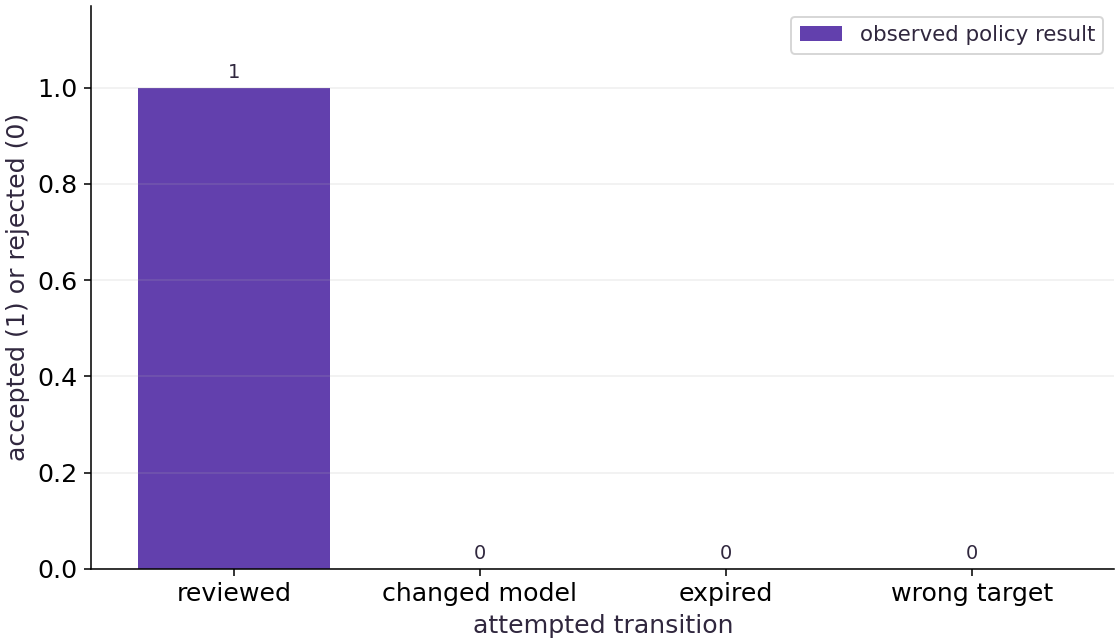

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal categories are four attempted transitions. Height $1$ means the local contract accepted the transition; height $0$ means it rejected it. Only the original reviewed bundle passes. Changed model content, expiration and target mismatch fail, and the program verifies that none changed the active pointer. Zero bars are observed rejections, not missing measurements.

### Connect it to the computation

This is a deterministic policy test, not a model-performance comparison or proof of authenticated approval. Use the real model/image identities and a trusted review process when transferring it to deployment.

## Test the exact expiry boundary

Predict: Is an approval still valid at its expiration timestamp?

In [7]:
# Experiment — Test the exact expiry boundary: Boundary conventions must be explicit.
# Assert invariant `verify_release(bundle` holds
assert verify_release(bundle,approval,199,'cpu-demo')
# Run the boundary check and catch the expected exception:
try:
    verify_release(bundle,approval,200,'cpu-demo')
except ValueError:
    print('Expiry is exclusive: 199 accepted, 200 rejected.')
else:
    raise AssertionError('expired approval accepted')

Expiry is exclusive: 199 accepted, 200 rejected.


Expected: Time 199 is accepted; 200 is rejected.

Boundary conventions must be explicit. Production clocks and identity systems need their own operational guarantees.

## Your exercise

Change the evaluation hash while keeping the model unchanged, and prove the old approval no longer applies.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `digest(...)` — Call `digest` with your updated parameters or inputs from this lesson's workspace.
- `verify_release(...)` — Call `verify_release` with your updated parameters or inputs from this lesson's workspace.

**Step-by-step implementation plan:**
1. Run the boundary check and catch the expected exception:

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Change the evaluation hash while keeping the model unchanged, and...
rechecked = dict(...)  # TODO: compute rechecked
# Run the boundary check and catch the expected exception:
try:
    verify_release(rechecked,approval,150,'cpu-demo')
except ValueError:
    print('Changed evaluation invalidates the old approval.')
else:
    raise AssertionError('stale approval accepted')
```

In [8]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Change the evaluation hash while keeping the model unchanged, and...
# rechecked = dict(...)  # TODO: compute rechecked
# Run the boundary check and catch the expected exception:
# try:
#     verify_release(rechecked,approval,150,'cpu-demo')
# except ValueError:
#     print('Changed evaluation invalidates the old approval.')
# else:
#     raise AssertionError('stale approval accepted')

## Reference solution

Try your own implementation first.

In [9]:
# Exercise solution: Change the evaluation hash while keeping the model unchanged, and...
rechecked=dict(bundle,evaluation_hash=digest({'high_slice_mse':9.}))
# Run the boundary check and catch the expected exception:
try:
    verify_release(rechecked,approval,150,'cpu-demo')
except ValueError:
    print('Changed evaluation invalidates the old approval.')
else:
    raise AssertionError('stale approval accepted')

Changed evaluation invalidates the old approval.


## Review a changed owner · transfer

Change the responsible owner and check whether the old bundle approval can be reused.

Hint: The owner is part of the reviewed release identity.

### How to write: Review a changed owner — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `owner(...)` — Call `owner` with your updated parameters or inputs from this lesson's workspace.
- `digest(...)` — Call `digest` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Review a changed owner (transfer): Ownership is an operational responsibility, so this policy...
2. Assert invariant `digest(changed_owner)!=approval['bundle_hash']` holds
3. Run the boundary check and catch the expected exception:

**Starter code scaffold (fill in the TODOs):**

```python
# Review a changed owner (transfer): Ownership is an operational responsibility, so this policy...
changed_owner = dict(...)  # TODO: compute changed_owner
# Assert invariant `digest(changed_owner)!=approval['bundle_hash']` holds
assert digest(changed_owner)  # TODO: complete assertion check
# Run the boundary check and catch the expected exception:
try:
    verify_release(changed_owner,approval,150,'cpu-demo')
except ValueError:
    print('Ownership change requires renewed review.')
else:
    raise AssertionError('changed owner accepted')
```

In [10]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Review a changed owner (transfer): Ownership is an operational responsibility, so this policy...
# changed_owner = dict(...)  # TODO: compute changed_owner
# Assert invariant `digest(changed_owner)!=approval['bundle_hash']` holds
# assert digest(changed_owner)  # TODO: complete assertion check
# Run the boundary check and catch the expected exception:
# try:
#     verify_release(changed_owner,approval,150,'cpu-demo')
# except ValueError:
#     print('Ownership change requires renewed review.')
# else:
#     raise AssertionError('changed owner accepted')

## Reference reasoning

Ownership is an operational responsibility, so this policy requires review after it changes. Organizations may choose different policies, but the rule must be explicit.

In [11]:
# Review a changed owner (transfer): Ownership is an operational responsibility, so this policy...
changed_owner=dict(bundle,owner='different-team')
# Assert invariant `digest(changed_owner)!=approval['bundle_hash']` holds
assert digest(changed_owner)!=approval['bundle_hash']
# Run the boundary check and catch the expected exception:
try:
    verify_release(changed_owner,approval,150,'cpu-demo')
except ValueError:
    print('Ownership change requires renewed review.')
else:
    raise AssertionError('changed owner accepted')

Ownership change requires renewed review.


## Checkpoint

An approval record contains a reviewer name and a matching hash. Does that authenticate the reviewer?

1. Yes, a hash verifies the reviewer identity.
2. No. The fixture checks binding and expiry; trusted identity and authorization are separate requirements.
3. Only if the model has low validation loss.

## Diagnose

Compare the whole bundle hash and target first, then time boundaries and reviewer authority. Never bypass a rejected rollout by editing a passed flag or pointing the alias manually. Keep the rejected transition in the incident record.

## Evidence

Keep the reviewed bundle hash, owner and target, expiry boundary, failed-transition pointer equality and changed-owner rejection. Explain why the local reviewer field is not authenticated approval.

## Carry forward

- Inventory the complete release
- Separate selection, rollout and monitoring
- Work through the four decisions

## Primary references

- [MLflow experiment tracking](https://mlflow.org/docs/latest/ml/tracking/quickstart/)
- [MLflow model registry workflows](https://mlflow.org/docs/latest/ml/model-registry/workflow/)
- [Kubernetes deployment rollout and rollback](https://kubernetes.io/docs/concepts/workloads/controllers/deployment/)